In [1]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.
from jaxopt import Bisection, Broyden, ScipyBoundedMinimize
import blackjax

import gpjax as gpx
from tensorflow_probability.substrates import jax as tfp
from tensorflow_probability.substrates.jax.mcmc import sample_halton_sequence

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

import sys
sys.path.append("..")
from src import GP, GPBanditSampler, HaltonSequence, MMD

In [2]:
#===========================================
# G and K model
#===========================================

def quantile(u, theta):
    zu = jsp.stats.norm.ppf(u)
    c0 = 0.8
    c1 = 1.0 + c0 * jnp.tanh(0.5*theta[2]*zu)
    c2 = ( 1.0 + zu**2 )**theta[3]
    return theta[0] + theta[1] * zu * c1 * c2

root_finding = Bisection(optimality_fun=lambda u, x, theta: quantile(u, theta) - x, lower=0.0, upper=1.0, check_bracket=False)
inv_quantile = lambda x, theta: root_finding.run(x=x, theta=theta).params
jac_quantile = jax.jacrev(quantile, argnums=0)

inv_quantile_vmap = jax.vmap(inv_quantile, in_axes=(0,None))
jac_quantile_vmap = jax.vmap(jac_quantile, in_axes=(0,None))

def logpdf_vmap(X, theta):
    inv_Q = inv_quantile_vmap(X, theta)
    jac_Q = jac_quantile_vmap(inv_Q, theta)
    log_Q = - jnp.log( jac_Q )
    return jnp.nan_to_num(log_Q, nan=-1000, posinf=1000, neginf=-1000)


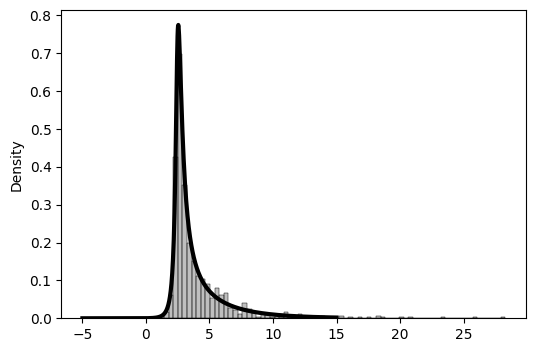

In [3]:
#===========================================
# Load Data
#===========================================

a = 3.0
b = 1.0
g = 2.0
k = 0.5
theta_0 = jnp.array([a, b, g, k])

data = jnp.load('Data/data.npy')

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plt_x = jnp.linspace(-5, 15, 1000)
sns.lineplot(x=plt_x, y=jnp.exp(logpdf_vmap(plt_x, theta_0)), color="black", linewidth=3, ax=ax)
sns.histplot(x=data, stat="density", alpha=0.5, color="gray", ax=ax)
plt.show()


In [4]:
#===========================================
# Posterior
#===========================================

@jax.jit
def loglikelihood(theta):
    return jnp.sum( logpdf_vmap(data, theta) )

@jax.jit
def logprior(theta):
    return - 4 * jnp.log( 10 )

@jax.jit
def logposterior(theta):
    return loglikelihood(theta) + logprior(theta)


In [5]:
#===========================================
# Excute
#===========================================

key = jrandom.key(0)
key, _key = jax.random.split(key)
n_init = 40
bounds = ( jnp.array([0.0, 0.0, 0.0, 0.0]), jnp.array([10.0, 10.0, 10.0, 10.0]) )
halton = HaltonSequence(dim=4, bounds=bounds, rngkey=_key)
bandit = GPBanditSampler(n_init=n_init, n_eval=320000, sequence=halton)
polyfm = PolynomialFeatures(degree=2, include_bias=False)

X = halton.generate(jnp.arange(n_init))
y = jnp.array([ logposterior(x) for x in X ])
w = jnp.exp( y - jsp.special.logsumexp( y ) )

for ith in tqdm(range(n_init, 400)):
    #====== fit GP ======
    pr = LinearRegression()
    pr.fit(polyfm.fit_transform(X), y)
    gp_mean = lambda x: 0.0
    gp_kernel = gpx.kernels.RBF(n_dims=4, lengthscale=jnp.array([1.0, 1.0, 1.0, 1.0]), variance=jnp.array([20.0]))
    gp = GP(gp_mean, gp_kernel)
    gp.tune_kernel_parameter(X, y - pr.predict(polyfm.fit_transform(X)), rng_key=_key)
    gp.fit(X, y - pr.predict(polyfm.fit_transform(X)))
    posterior_mean = jax.vmap(gp.posterior_mean, in_axes=0, out_axes=0)
    posterior_scale = jax.vmap(gp.posterior_scale, in_axes=0, out_axes=0)
    objective_gp = jax.vmap(gp.log_jensen_exp, in_axes=0, out_axes=0)
    objective = lambda Z: pr.predict(polyfm.fit_transform(Z)) + objective_gp(Z)
    #====================
    
    #====== fit KH ======
    X_new = bandit.find(objective)
    y_new = logposterior(X_new)
    #====================
    
    #=== Stack point ====
    X = jnp.vstack((X, X_new))
    y = jnp.hstack((y, y_new))
    w = jnp.exp( y - jsp.special.logsumexp( y ) )
    #====================


  0%|                                                                                              | 0/360 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|▏                                                                                     | 1/360 [00:01<08:37,  1.44s/it]

  0%|          | 0/1000 [00:00<?, ?it/s]

  1%|▍                                                                                     | 2/360 [00:02<07:15,  1.22s/it]

...

 99%|███████████████████████████████████████████████████████████████████████████████████▌| 358/360 [27:03<00:20, 10.41s/it]

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████▊| 359/360 [27:15<00:10, 10.74s/it]

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████| 360/360 [27:27<00:00,  4.58s/it]


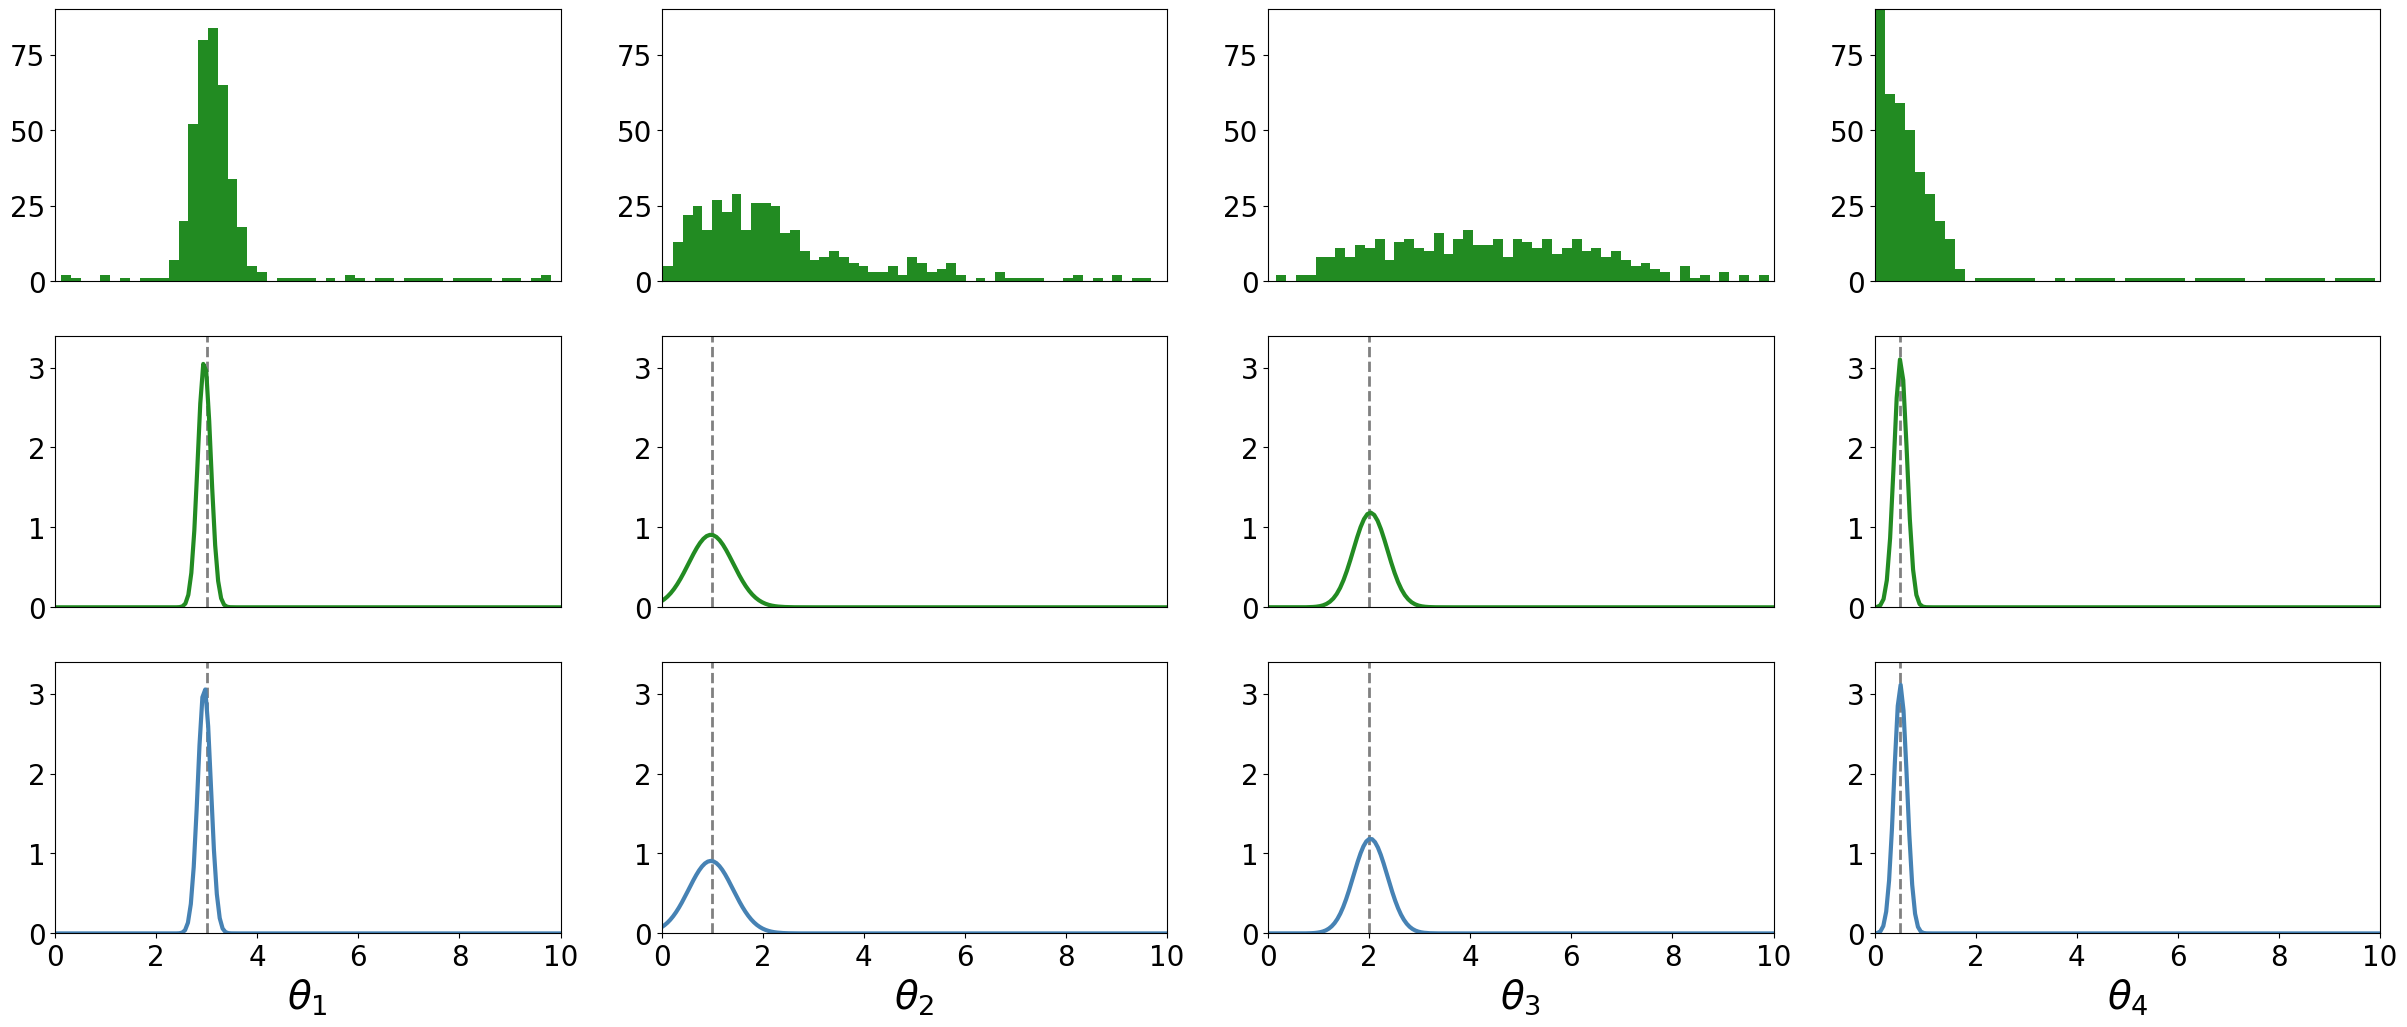

In [6]:
#===========================================
# Plot
#===========================================
from matplotlib.ticker import FormatStrFormatter

samples = jnp.load('Data/samples.npy')
weights = jnp.load('Data/weights.npy')

fig, axs = plt.subplots(3, 4, figsize=(30, 12))

for i in range(4):
    axs[0,i].hist(X[:,i], bins=50, color="forestgreen", zorder=2)
    axs[0,i].set_xlim(0, 10)
    axs[0,i].set_ylim(0, 90)
    axs[0,i].set_ylabel("")
    axs[0,i].set_xlabel("")
    axs[0,i].tick_params(axis='both', which='major', labelsize=20)
    axs[0,i].set_xticks([])

for i in range(4):
    sns.kdeplot(x=X[:,i], weights=w, linewidth=3, zorder=2, color="forestgreen", ax=axs[1,i])
    axs[1,i].vlines(theta_0[i], 0, 5, linewidth=2, linestyle="--", color="gray", zorder=1)
    axs[1,i].set_xlim(0, 10)
    axs[1,i].set_ylim(0, 3.4)
    axs[1,i].set_ylabel("")
    axs[1,i].set_xlabel("")
    axs[1,i].tick_params(axis='both', which='major', labelsize=20)
    axs[1,i].set_xticks([])

for i in range(4):
    sns.kdeplot(x=samples[:,i], weights=weights, color="steelblue", linewidth=3, zorder=2, ax=axs[2,i])
    axs[2,i].vlines(theta_0[i], 0, 5, linewidth=2, linestyle="--", color="gray", zorder=1)
    axs[2,i].set_xlim(0, 10)
    axs[2,i].set_ylim(0, 3.4)
    axs[2,i].set_ylabel("")
    axs[2,i].set_xlabel(r"$\theta_{:d}$".format(i+1), fontsize=28)
    axs[2,i].tick_params(axis='both', which='major', labelsize=20)
    